## Step 1: Install Dependencies

In [ ]:
!pip install insightface onnxruntime-gpu -q
!pip install scikit-learn seaborn -q
print("✓ Dependencies installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 32.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.7 MB/s eta 0:00:00
✓ Dependencies installed


## Step 2: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✓ Drive mounted")

Mounted at /content/drive
✓ Drive mounted


## Step 3: Import Libraries

In [ ]:
import cv2
import json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from insightface.app import FaceAnalysis

print("✓ Libraries imported")

✓ Libraries imported


## Step 4: Configuration

In [ ]:
BASE_PATH = Path("/content/drive/MyDrive/face_pipeline_project")
FRAMES_FOLDER = BASE_PATH / "extracted_frames"
FACE_CROPS_FOLDER = BASE_PATH / "face_crops_aligned"
KEYPOINTS_FOLDER = BASE_PATH / "keypoints"
METRICS_FOLDER = BASE_PATH / "metrics"
GROUND_TRUTH_FOLDER = BASE_PATH / "ground_truth"
CHECKPOINT_FILE = BASE_PATH / "checkpoint_face.json"

FACE_CONFIDENCE_THRESHOLD = 0.7
OUTPUT_SIZE = (224, 224)
PADDING_RATIO = 0.15  # 15% padding around aligned face


FACE_CROPS_FOLDER.mkdir(exist_ok=True, parents=True)
KEYPOINTS_FOLDER.mkdir(exist_ok=True, parents=True)
METRICS_FOLDER.mkdir(exist_ok=True, parents=True)

print(f"Input: {FRAMES_FOLDER}")
print(f"Output: {FACE_CROPS_FOLDER}")
print(f"Confidence threshold: {FACE_CONFIDENCE_THRESHOLD}")
print(f"Output size: {OUTPUT_SIZE}")
print(f"Padding: {PADDING_RATIO*100}%")

Input: /content/drive/MyDrive/face_pipeline_project/extracted_frames
Output: /content/drive/MyDrive/face_pipeline_project/face_crops_aligned
Confidence threshold: 0.7
Output size: (224, 224)
Padding: 15.0%


## Step 5: Face Alignment Function

In [ ]:
def align_face(img, kps, output_size=(224, 224)):
    """
    Align face using 5-point landmarks via similarity transform.
    - Rotates face so eyes are horizontal
    - Scales to canonical size
    - Centers nose/eyes consistently
    """
    # ArcFace reference landmarks for 224x224
    ref_kps = np.array([
        [70.745, 112.0],   # left eye
        [153.255, 112.0],  # right eye
        [112.0, 153.255],  # nose
        [82.0, 176.745],   # left mouth
        [142.0, 176.745],  # right mouth
    ], dtype=np.float32)

    kps = kps.astype(np.float32)

    # Similarity transform (rotation + scale + translation)
    M, _ = cv2.estimateAffinePartial2D(kps, ref_kps, method=cv2.LMEDS)
    if M is None:
        return None

    aligned = cv2.warpAffine(
        img, M, output_size,
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REPLICATE
    )
    return aligned

print("✓ Face alignment function ready")

✓ Face alignment function ready


## Step 6: Checkpoint Functions

In [ ]:
def load_checkpoint():
    if CHECKPOINT_FILE.exists():
        with open(CHECKPOINT_FILE, 'r') as f:
            cp = json.load(f)
            print(f"✓ Checkpoint: {len(cp.get('completed_videos', []))} videos done")
            return cp
    return {'completed_videos': [], 'current_video': None, 'total_faces': 0}

def save_checkpoint(cp):
    cp['last_updated'] = datetime.now().isoformat()
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump(cp, f, indent=2)

def mark_complete(cp, video_name, faces_count):
    cp['completed_videos'].append(video_name)
    cp['current_video'] = None
    cp['total_faces'] += faces_count
    save_checkpoint(cp)

checkpoint = load_checkpoint()

✓ Checkpoint: 17 videos done


## Step 7: List Videos to Process

In [ ]:
video_folders = sorted([f for f in FRAMES_FOLDER.iterdir() if f.is_dir()])
completed = set(checkpoint['completed_videos'])
remaining = [v for v in video_folders if v.name not in completed]

print(f"Total: {len(video_folders)} | Completed: {len(completed)} | Remaining: {len(remaining)}")

Total: 31 | Completed: 17 | Remaining: 14


## Step 8: Load SCRFD Model

In [ ]:
print("Loading SCRFD model...")
face_app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
face_app.prepare(ctx_id=0, det_size=(640, 640))
print("✓ SCRFD model loaded")

Loading SCRFD model...
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 96862.10KB/s] 


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

## Step 9: Process Frames - Detect, Align & Save Faces

In [9]:
# Load existing detections
detections_file = METRICS_FOLDER / "face_detections.csv"
if detections_file.exists():
    all_detections = pd.read_csv(detections_file).to_dict('records')
else:
    all_detections = []

for video_folder in remaining:
    video_name = video_folder.name
    print(f"\n{'='*50}")
    print(f"Processing: {video_name}")
    print(f"{'='*50}")

    # Create output folders
    face_output = FACE_CROPS_FOLDER / video_name
    kp_output = KEYPOINTS_FOLDER / video_name
    face_output.mkdir(exist_ok=True)
    kp_output.mkdir(exist_ok=True)

    frames = sorted(list(video_folder.glob("*.jpg")))
    print(f"Frames to process: {len(frames)}")

    face_count = 0
    skipped_low_conf = 0
    skipped_no_kps = 0
    skipped_align_fail = 0
    checkpoint['current_video'] = video_name

    for frame_path in tqdm(frames, desc="Detecting & aligning"):
        img = cv2.imread(str(frame_path))
        if img is None:
            continue

        h, w = img.shape[:2]
        faces = face_app.get(img)

        frame_has_face = 0

        for i, face in enumerate(faces):
            # Check confidence
            if face.det_score < FACE_CONFIDENCE_THRESHOLD:
                skipped_low_conf += 1
                continue

            # Check keypoints exist
            if face.kps is None:
                skipped_no_kps += 1
                continue

            # Align face using landmarks
            aligned_face = align_face(img, face.kps, output_size=OUTPUT_SIZE)
            if aligned_face is None:
                skipped_align_fail += 1
                continue
            # Save aligned face directly (no padding needed)
            face_filename = f"{frame_path.stem}_face_{i}.jpg"
            cv2.imwrite(str(face_output / face_filename), aligned_face)
            # Save keypoints
            kp_filename = f"{frame_path.stem}_face_{i}.npy"
            np.save(str(kp_output / kp_filename), face.kps)
            face_count += 1
            frame_has_face = 1

        # Log detection
        all_detections.append({
            'video': video_name,
            'frame': frame_path.name,
            'faces_detected': len([f for f in faces if f.det_score >= FACE_CONFIDENCE_THRESHOLD]),
            'face_present': frame_has_face
        })

    mark_complete(checkpoint, video_name, face_count)
    print(f"✓ Saved {face_count} aligned faces")
    print(f"  Skipped: {skipped_low_conf} low conf, {skipped_no_kps} no kps, {skipped_align_fail} align fail")

    # Save after each video
    pd.DataFrame(all_detections).to_csv(detections_file, index=False)

print(f"\n✅ COMPLETE! Total: {checkpoint['total_faces']} aligned faces")


Processing: 11.07.48-11.40.41[M][0@0][99358]_ch1 (1)
Frames to process: 1576


Detecting & aligning: 100%|██████████| 1576/1576 [35:51<00:00,  1.37s/it]


✓ Saved 1125 aligned faces
  Skipped: 1225 low conf, 0 no kps, 0 align fail

Processing: 11.12.25-11.37.18[M][0@0][41791]_ch1 (1)
Frames to process: 1143


Detecting & aligning: 100%|██████████| 1143/1143 [02:42<00:00,  7.04it/s]


✓ Saved 791 aligned faces
  Skipped: 599 low conf, 0 no kps, 0 align fail

Processing: 11.30.31-11.42.14[M][0@0][128605]_ch1
Frames to process: 85


...

✓ Saved 224 aligned faces
  Skipped: 301 low conf, 0 no kps, 0 align fail

Processing: 15.52.42-16.07.48[M][0@0][17210]_ch1
Frames to process: 574


Detecting & aligning: 100%|██████████| 574/574 [01:10<00:00,  8.09it/s]


✓ Saved 756 aligned faces
  Skipped: 310 low conf, 0 no kps, 0 align fail

Processing: 16.10.25-16.37.17[M][0@0][123219]_ch1
Frames to process: 1025


Detecting & aligning: 100%|██████████| 1025/1025 [01:31<00:00, 11.22it/s]


✓ Saved 308 aligned faces
  Skipped: 306 low conf, 0 no kps, 0 align fail

✅ COMPLETE! Total: 31041 aligned faces


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Create Ground Truth Template

In [10]:
df_det = pd.read_csv(METRICS_FOLDER / "face_detections.csv")

SAMPLE_SIZE = 200
df_sample = df_det.sample(n=min(SAMPLE_SIZE, len(df_det)), random_state=42)
df_sample = df_sample.sort_values(['video', 'frame']).reset_index(drop=True)

print(f"Total frames processed: {len(df_det)}")
print(f"Sampled for labeling: {len(df_sample)}")

# Save template
df_sample['actual_face_present'] = ''
gt_path = GROUND_TRUTH_FOLDER / "face_detection_labels.csv"
df_sample.to_csv(gt_path, index=False)
print(f"✓ Saved: {gt_path}")

Total frames processed: 50462
Sampled for labeling: 200
✓ Saved: /content/drive/MyDrive/face_pipeline_project/ground_truth/face_detection_labels.csv


# Interactive Face Detection Labeling

In [11]:
from IPython.display import display, clear_output, Image as IPImage
import ipywidgets as widgets

# Get all face crops for labeling
all_crops = []
for video_folder in FACE_CROPS_FOLDER.iterdir():
    if video_folder.is_dir():
        for face_file in video_folder.glob("*.jpg"):
            all_crops.append({
                'video': video_folder.name,
                'face_file': face_file.name,
                'full_path': str(face_file)
            })

df_crops = pd.DataFrame(all_crops)
print(f"Total face crops: {len(df_crops)}")

# Sample for labeling
SAMPLE_SIZE = 200
df_sample = df_crops.sample(n=min(SAMPLE_SIZE, len(df_crops)), random_state=42).reset_index(drop=True)
print(f"Sampled for labeling: {len(df_sample)}")

# Load existing labels if resuming
LABELS_FILE = GROUND_TRUTH_FOLDER / "face_crop_labels.csv"
if LABELS_FILE.exists():
    df_existing = pd.read_csv(LABELS_FILE)
    existing_files = set(df_existing['face_file'].tolist())
    labels = df_existing.set_index(df_existing.index)['is_actual_face'].to_dict()
    print(f"Loaded {len(df_existing)} existing labels")
else:
    labels = {}

current_idx = [0]

def save_labels():
    df_sample['is_actual_face'] = df_sample.index.map(lambda x: labels.get(x, ''))
    df_sample.to_csv(LABELS_FILE, index=False)
    return len([v for v in labels.values() if v != ''])

def show_face(idx):
    clear_output(wait=True)

    if idx >= len(df_sample):
        total = save_labels()
        print("✅ LABELING COMPLETE!")
        print(f"Labeled: {total}")
        print(f"Saved to: {LABELS_FILE}")
        return

    row = df_sample.iloc[idx]
    labeled_count = len([v for v in labels.values() if v != ''])

    print(f"Image {idx + 1} / {len(df_sample)}  |  Labeled: {labeled_count}")
    print(f"Video: {row['video']}")
    print(f"File: {row['face_file']}")

    # Display image at original size
    display(IPImage(filename=row['full_path']))

    # Buttons
    btn_face = widgets.Button(description="✓ IS A FACE", button_style='success', layout=widgets.Layout(width='150px', height='50px'))
    btn_not = widgets.Button(description="✗ NOT A FACE", button_style='danger', layout=widgets.Layout(width='150px', height='50px'))
    btn_skip = widgets.Button(description="Skip", layout=widgets.Layout(width='100px'))
    btn_back = widgets.Button(description="← Back", layout=widgets.Layout(width='100px'))
    btn_save = widgets.Button(description="💾 Save", button_style='info', layout=widgets.Layout(width='100px'))

    def on_face(b):
        labels[idx] = 1
        current_idx[0] += 1
        show_face(current_idx[0])

    def on_not(b):
        labels[idx] = 0
        current_idx[0] += 1
        show_face(current_idx[0])

    def on_skip(b):
        current_idx[0] += 1
        show_face(current_idx[0])

    def on_back(b):
        if current_idx[0] > 0:
            current_idx[0] -= 1
            show_face(current_idx[0])

    def on_save(b):
        total = save_labels()
        print(f"💾 Saved {total} labels to {LABELS_FILE}")

    btn_face.on_click(on_face)
    btn_not.on_click(on_not)
    btn_skip.on_click(on_skip)
    btn_back.on_click(on_back)
    btn_save.on_click(on_save)

    display(widgets.HBox([btn_face, btn_not]))
    display(widgets.HBox([btn_skip, btn_back, btn_save]))

# Start
print("🏁 Starting Face Detection Labeling...")
show_face(0)

✅ LABELING COMPLETE!
Labeled: 200
Saved to: /content/drive/MyDrive/face_pipeline_project/ground_truth/face_crop_labels.csv


# Confusion Matrix

Labeled crops: 200


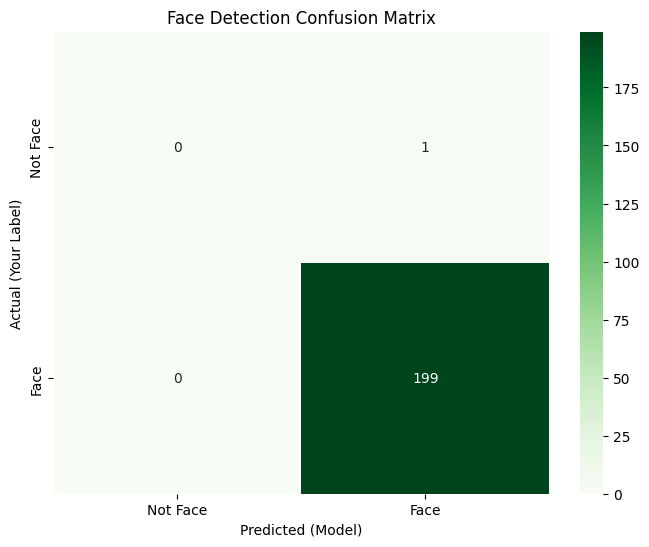


FACE DETECTION RESULTS
Total crops checked: 200
True Positives (actual faces): 199
False Positives (not faces): 1
Precision: 99.5%

✓ Report saved


In [15]:
LABELS_FILE = GROUND_TRUTH_FOLDER / "face_crop_labels.csv"

try:
    df_gt = pd.read_csv(LABELS_FILE)

    # Filter labeled rows
    df_labeled = df_gt[df_gt['is_actual_face'].notna() & (df_gt['is_actual_face'] != '')].copy()

    if len(df_labeled) == 0:
        print("⚠️ No labels found! Run Step 11 first.")
    else:
        print(f"Labeled crops: {len(df_labeled)}")

        df_labeled['is_actual_face'] = df_labeled['is_actual_face'].astype(int)

        y_true = df_labeled['is_actual_face'].values
        y_pred = np.ones(len(y_true), dtype=int)

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                    xticklabels=['Not Face', 'Face'],
                    yticklabels=['Not Face', 'Face'])
        plt.xlabel('Predicted (Model)')
        plt.ylabel('Actual (Your Label)')
        plt.title('Face Detection Confusion Matrix')
        plt.savefig(METRICS_FOLDER / "confusion_matrix_face.png", dpi=150)
        plt.show()

        # Metrics
        true_pos = (y_true == 1).sum()
        false_pos = (y_true == 0).sum()
        precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0

        print(f"\n{'='*40}")
        print(f"FACE DETECTION RESULTS")
        print(f"{'='*40}")
        print(f"Total crops checked: {len(y_true)}")
        print(f"True Positives (actual faces): {true_pos}")
        print(f"False Positives (not faces): {false_pos}")
        print(f"Precision: {precision:.1%}")

        # Save report
        report = pd.DataFrame({
            'Metric': ['Total', 'True Positives', 'False Positives', 'Precision'],
            'Value': [len(y_true), true_pos, false_pos, f"{precision:.1%}"]
        })
        report.to_csv(METRICS_FOLDER / "classification_report_face.csv", index=False)
        print(f"\n✓ Report saved")

except FileNotFoundError:
    print("⚠️ Run labeling (Step 11) first!")

##  Display Sample Aligned Faces

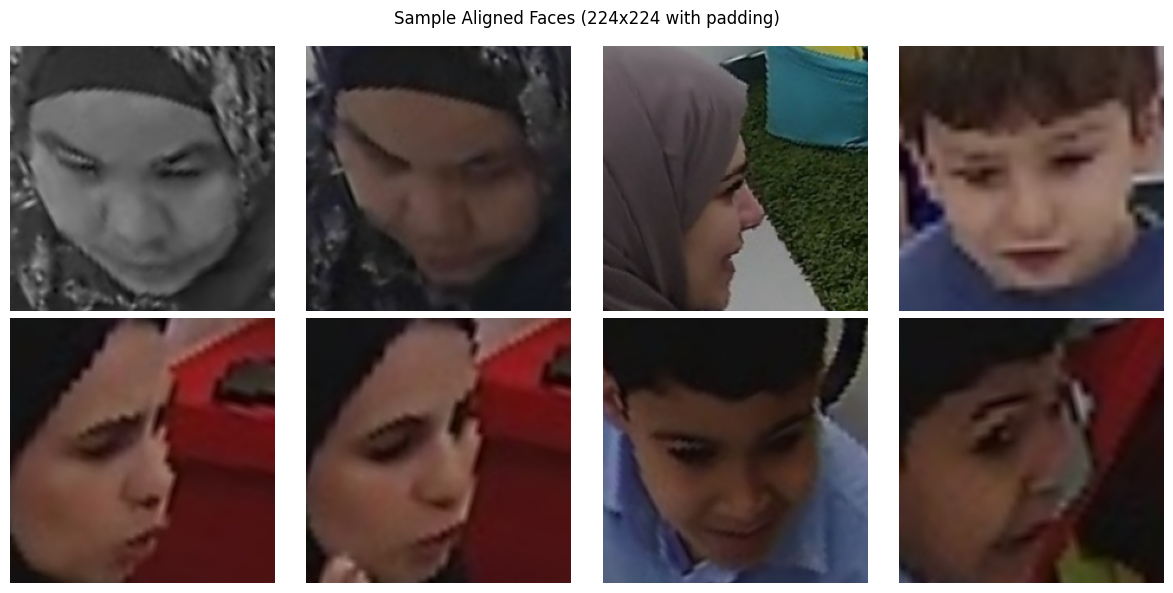

In [13]:
sample_faces = []
for folder in FACE_CROPS_FOLDER.iterdir():
    if folder.is_dir():
        faces = list(folder.glob("*.jpg"))[:2]
        sample_faces.extend(faces)
    if len(sample_faces) >= 8:
        break

if sample_faces:
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i, face_path in enumerate(sample_faces[:8]):
        img = cv2.imread(str(face_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax = axes[i // 4, i % 4]
        ax.imshow(img)
        ax.axis('off')
    plt.suptitle("Sample Aligned Faces (224x224 with padding)")
    plt.tight_layout()
    plt.show()